In [55]:
import numpy as np
import scipy.constants as const
import scipy.optimize as opt
from scipy.signal import find_peaks
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
import pandas as pd
import os
import copy
import h5py
import json
import importlib
import optical_tweezers_function_file
import save_results_function_file   
importlib.reload(optical_tweezers_function_file)
importlib.reload(save_results_function_file)
from save_results_function_file import *
from optical_tweezers_function_file import *
from IPython.display import HTML
plt.rcParams["animation.html"] = "jshtml"

%load_ext line_profiler

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


# Optical lattice propagation in x

In [2]:
#Parameters
Re_alpha_lat = au_to_SI(270)                                        #A^2s^4/kg
P = 1                                                               #W
w01, w02 = 650e-6, 650e-6                                           #m
wavelength = 532e-9                                                 #m
w1, w2 = 2*np.pi*nm_to_Hz(wavelength), 2*np.pi*nm_to_Hz(wavelength) #Hz
#Variables
x = np.linspace(-5*wavelength, 5*wavelength, 500)                   #m
y = np.linspace(-10e-3, 10e-3, 500)                                 #m
z = np.linspace(-10e-3, 10e-3, 500)                                 #m

In [3]:
#U_x_y_z
U_x_0_0_latt = optical_dipole_trap_2_beams_rotated(x, 0, 0, 0, Re_alpha_lat, P, w01, w02, wavelength, w1, w2)   #J
latt_depth_x = np.mean(lattice_depth_2_beams_rotated(x, 0, 0, Re_alpha_lat, P, w01, w02, wavelength, 0, 0))     #J
U_0_latt_x = U_0_latt_2_beams_rotated(x, 0, 0, Re_alpha_lat, P, w01, w02, wavelength, 0, 0)                     #J

U_0_y_0_latt = optical_dipole_trap_2_beams_rotated(0, y, 0, 0, Re_alpha_lat, P, w01, w02, wavelength, w1, w2)   #J
latt_depth_y = np.mean(lattice_depth_2_beams_rotated(0, y, 0, Re_alpha_lat, P, w01, w02, wavelength, 0, 0))     #J
U_0_latt_y = U_0_latt_2_beams_rotated(0, y, 0, Re_alpha_lat, P, w01, w02, wavelength, 0, 0)                     #J

U_0_0_z_latt = optical_dipole_trap_2_beams_rotated(0, 0, z, 0, Re_alpha_lat, P, w01, w02, wavelength, w1, w2)   #J
latt_depth_z = np.mean(lattice_depth_2_beams_rotated(0, 0, z, Re_alpha_lat, P, w01, w02, wavelength, 0, 0))     #J
U_0_latt_z = U_0_latt_2_beams_rotated(0, 0, z, Re_alpha_lat, P, w01, w02, wavelength, 0, 0)                     #J

#I_x_y_z
I1 = gaussian_beam_rotated(x, 0, 0, P, w01, wavelength, z0=0)                                                 #W/m^2
I2 = gaussian_beam_rotated(x, 0, 0, P, w02, wavelength, z0=0)                                                 #W/m^2
I_latt_0_0_x = two_gaussian_beams_rotated(x, 0, I1, I2, w1, w2, wavelength)                                           #W/m^2

I1 = gaussian_beam_rotated(0, y, 0, P, w01, wavelength, z0=0)                                                 #W/m^2
I2 = gaussian_beam_rotated(0, y, 0, P, w02, wavelength, z0=0)                                                 #W/m^2
I_latt_0_y_0 = two_gaussian_beams_rotated(0, 0, I1, I2, w1, w2, wavelength)                                           #W/m^2

I1 = gaussian_beam_rotated(0, 0, z, P, w01, wavelength, z0=0)                                                 #W/m^2
I2 = gaussian_beam_rotated(0, 0, z, P, w02, wavelength, z0=0)                                                 #W/m^2
I_latt_0_0_z = two_gaussian_beams_rotated(0, 0, I1, I2, w1, w2, wavelength)                                           #W/m^2

#Recoil energy
E_r = recoil_energy(m_yb, wavelength)

Lattice depth: 5.0540522633903975e-30 J


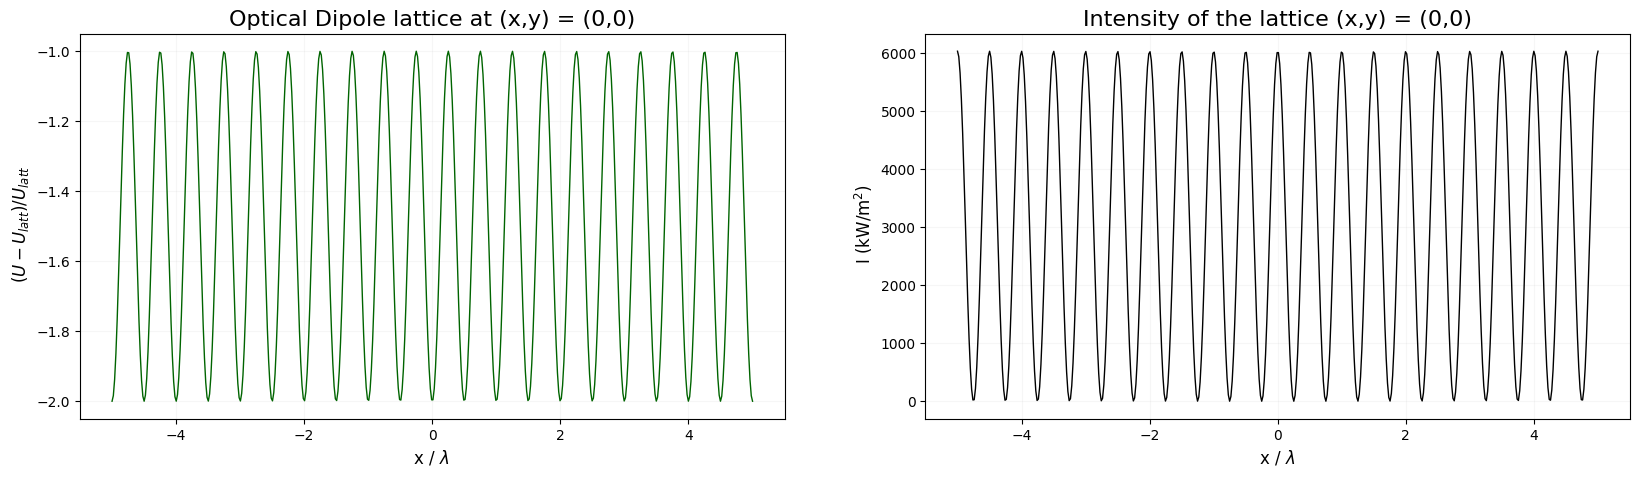

In [4]:
print('Lattice depth:', latt_depth_x, 'J')
fig, axes = plt.subplots(1, 2, figsize=(20,5))
axes[0].plot(x/wavelength, (U_x_0_0_latt-latt_depth_x)/latt_depth_x,  color='darkgreen', linewidth=1, markersize = 1)
axes[0].set_title('Optical Dipole lattice at (x,y) = (0,0)', fontsize=16)
axes[0].set_xlabel(r'x / $\lambda$ ', fontsize=12)
axes[0].set_ylabel(r' $(U-U_{latt})/U_{latt}$', fontsize=12)
#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.1)

axes[1].plot(x/wavelength, I_latt_0_0_x*1e-3, linestyle='-', color='black', linewidth=1, markersize = 3)
axes[1].set_title('Intensity of the lattice (x,y) = (0,0)', fontsize=16)
axes[1].set_xlabel(r'x / $\lambda$ ', fontsize=12)
axes[1].set_ylabel(r' I (kW/m$^2$)', fontsize=12)
#axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.1)
plt.show()

In [5]:
idx0 = np.argmin(np.abs(x-0))
idx1 = np.argmin(np.abs(x+wavelength/2))
idx2 = np.argmin(np.abs(x-wavelength/2))
idx_max_1 = np.argmax(U_x_0_0_latt[idx1:idx0]) + idx1
idx_max_2 = np.argmax(U_x_0_0_latt[idx0:idx2]) + idx0
U_single = U_x_0_0_latt[idx_max_1:idx_max_2]
x_single = x[idx_max_1:idx_max_2]

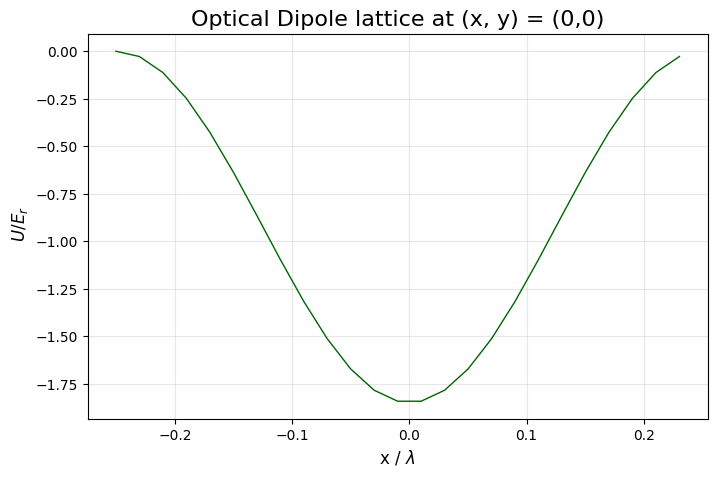

In [6]:
plt.figure(figsize=(8,5))
plt.plot(x_single/wavelength, U_single/E_r,  color='darkgreen', linewidth=1, markersize = 1)
plt.title('Optical Dipole lattice at (x, y) = (0,0)', fontsize=16)
plt.xlabel(r'x / $\lambda$ ', fontsize=12)
plt.ylabel(r' $U / E_r$', fontsize=12)
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

Lattice depth: 2.054535119694237e-31 J


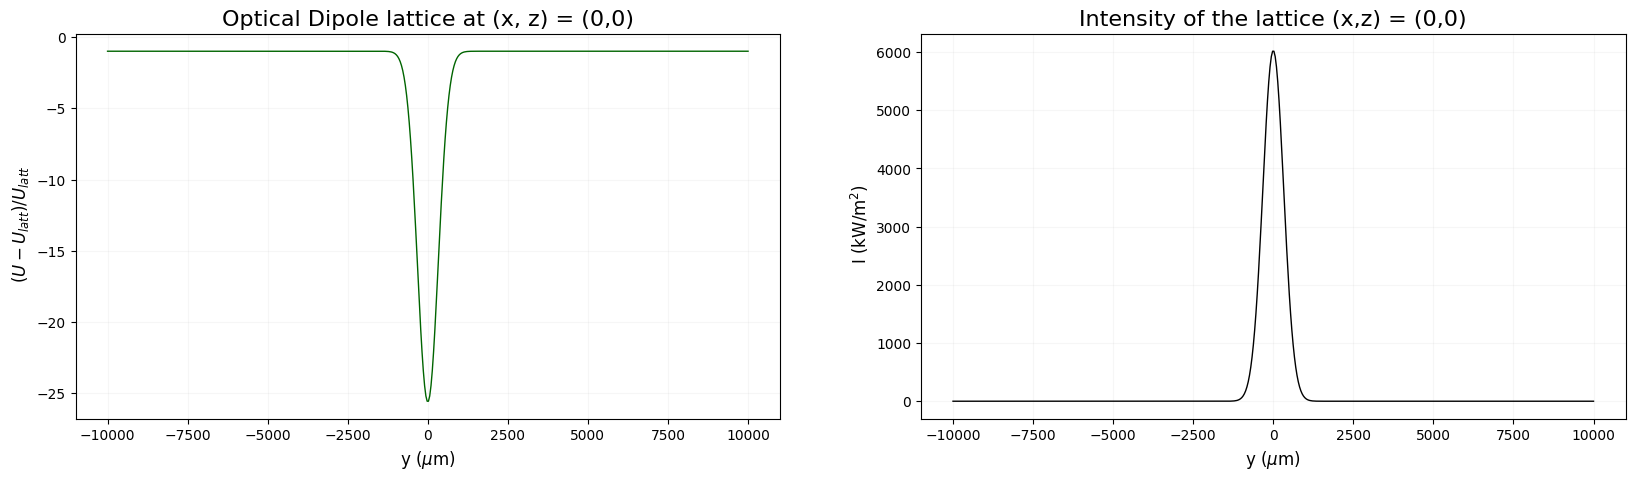

In [7]:
print('Lattice depth:', latt_depth_y, 'J')
fig, axes = plt.subplots(1, 2, figsize=(20,5))
axes[0].plot(y*1e6, (U_0_y_0_latt-latt_depth_y)/latt_depth_y,  color='darkgreen', linewidth=1, markersize = 1)
axes[0].set_title('Optical Dipole lattice at (x, z) = (0,0)', fontsize=16)
axes[0].set_xlabel(r'y ($\mu$m)', fontsize=12)
axes[0].set_ylabel(r' $(U-U_{latt})/U_{latt}$', fontsize=12)
#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.1)

axes[1].plot(y*1e6, I_latt_0_y_0*1e-3, linestyle='-', color='black', linewidth=1, markersize = 3)
axes[1].set_title('Intensity of the lattice (x,z) = (0,0)', fontsize=16)
axes[1].set_xlabel(r'y ($\mu$m) ', fontsize=12)
axes[1].set_ylabel(r' I (kW/m$^2$)', fontsize=12)
#axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.1)
plt.show()

Lattice depth: 2.054535119694237e-31 J


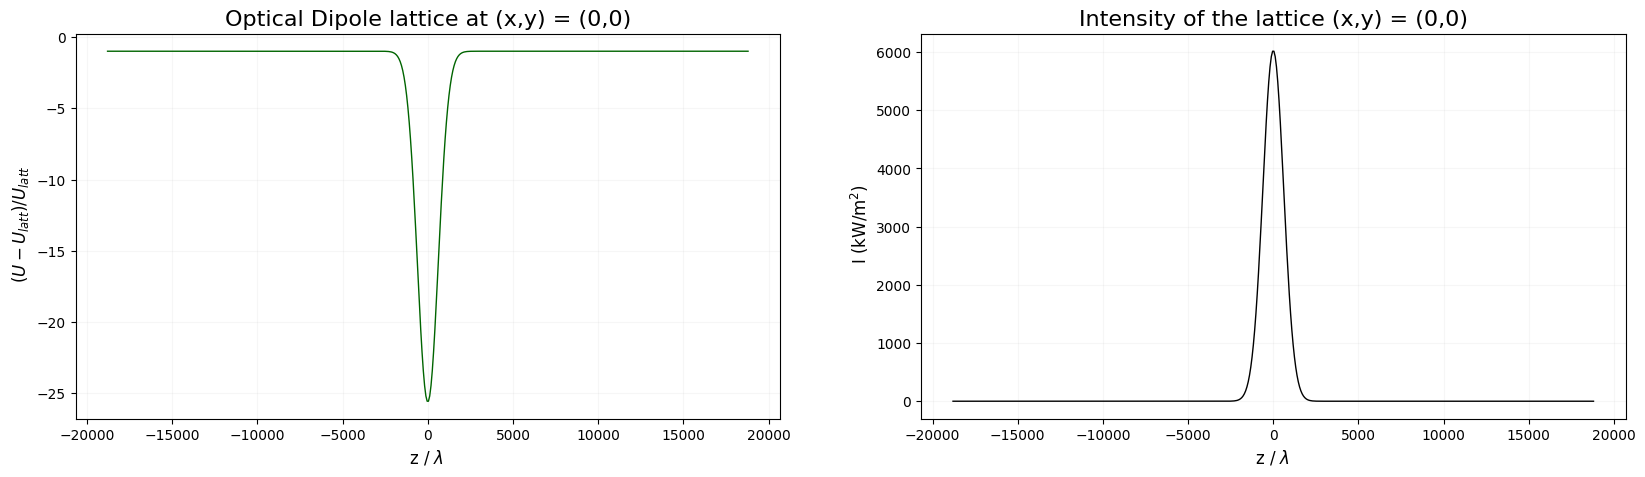

In [8]:
print('Lattice depth:', latt_depth_z, 'J')
fig, axes = plt.subplots(1, 2, figsize=(20,5))
axes[0].plot(z/wavelength, (U_0_0_z_latt-latt_depth_z)/latt_depth_z,  color='darkgreen', linewidth=1, markersize = 1)
axes[0].set_title('Optical Dipole lattice at (x,y) = (0,0)', fontsize=16)
axes[0].set_xlabel(r'z / $\lambda$ ', fontsize=12)
axes[0].set_ylabel(r' $(U-U_{latt})/U_{latt}$', fontsize=12)
#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.1)

axes[1].plot(z/wavelength, I_latt_0_0_z*1e-3, linestyle='-', color='black', linewidth=1, markersize = 3)
axes[1].set_title('Intensity of the lattice (x,y) = (0,0)', fontsize=16)
axes[1].set_xlabel(r'z / $\lambda$ ', fontsize=12)
axes[1].set_ylabel(r' I (kW/m$^2$)', fontsize=12)
#axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.1)
plt.show()

# Optical lattice propagation in z

In [9]:
#Parameters
Re_alpha_lat = au_to_SI(270)                                        #A^2s^4/kg
P = 1                                                               #W
w01, w02 = 650e-6, 650e-6                                           #m
wavelength = 532e-9                                                 #m
w1, w2 = 2*np.pi*nm_to_Hz(wavelength), 2*np.pi*nm_to_Hz(wavelength) #Hz
#Variables
z = np.linspace(-5*wavelength, 5*wavelength, 500)                   #m
x = np.linspace(-10e-3, 10e-3, 500)                                 #m
y = np.linspace(-10e-3, 10e-3, 500)                                 #m


In [10]:
#U_x_y_z
U_0_0_z_latt = optical_dipole_trap_2_beams(0, 0, z, 0, Re_alpha_lat, P, w01, w02, wavelength, w1, w2) #J
latt_depth_z = np.mean(lattice_depth_2_beams(0, 0, z, Re_alpha_lat, P, w01, w02, wavelength, 0, 0))     #J

U_x_0_0_latt = optical_dipole_trap_2_beams(x, 0, 0, 0, Re_alpha_lat, P, w01, w02, wavelength, w1, w2) #J
latt_depth_x = np.mean(lattice_depth_2_beams(x, 0, 0, Re_alpha_lat, P, w01, w02, wavelength, 0, 0))     #J

U_0_y_0_latt = optical_dipole_trap_2_beams(0, y, 0, 0, Re_alpha_lat, P, w01, w02, wavelength, w1, w2) #J
latt_depth_y = np.mean(lattice_depth_2_beams(0, y, 0, Re_alpha_lat, P, w01, w02, wavelength, 0, 0))     #J
#I_x_y_z
I1 = gaussian_beam(0, 0, z, P, w01, wavelength, z0=0)                                                 #W/m^2
I2 = gaussian_beam(0, 0, z, P, w02, wavelength, z0=0)                                                 #W/m^2
I_latt_0_0_z = two_gaussian_beams(z, 0, I1, I2, w1, w2, wavelength)                                   #W/m^2

I1 = gaussian_beam(x, 0, 0, P, w01, wavelength, z0=0)                                                 #W/m^2
I2 = gaussian_beam(x, 0, 0, P, w02, wavelength, z0=0)                                                 #W/m^2
I_latt_x_0_0 = two_gaussian_beams(0, 0, I1, I2, w1, w2, wavelength)                                   #W/m^2

I1 = gaussian_beam(0, y, 0, P, w01, wavelength, z0=0)                                                 #W/m^2
I2 = gaussian_beam(0, y, 0, P, w02, wavelength, z0=0)                                                 #W/m^2
I_latt_0_y_0 = two_gaussian_beams(0, 0, I1, I2, w1, w2, wavelength)                                   #W/m^2

#Recoil energy
E_r = recoil_energy(m_yb, wavelength)

### z-dependence

Lattice depth: 5.0540522633903975e-30 J


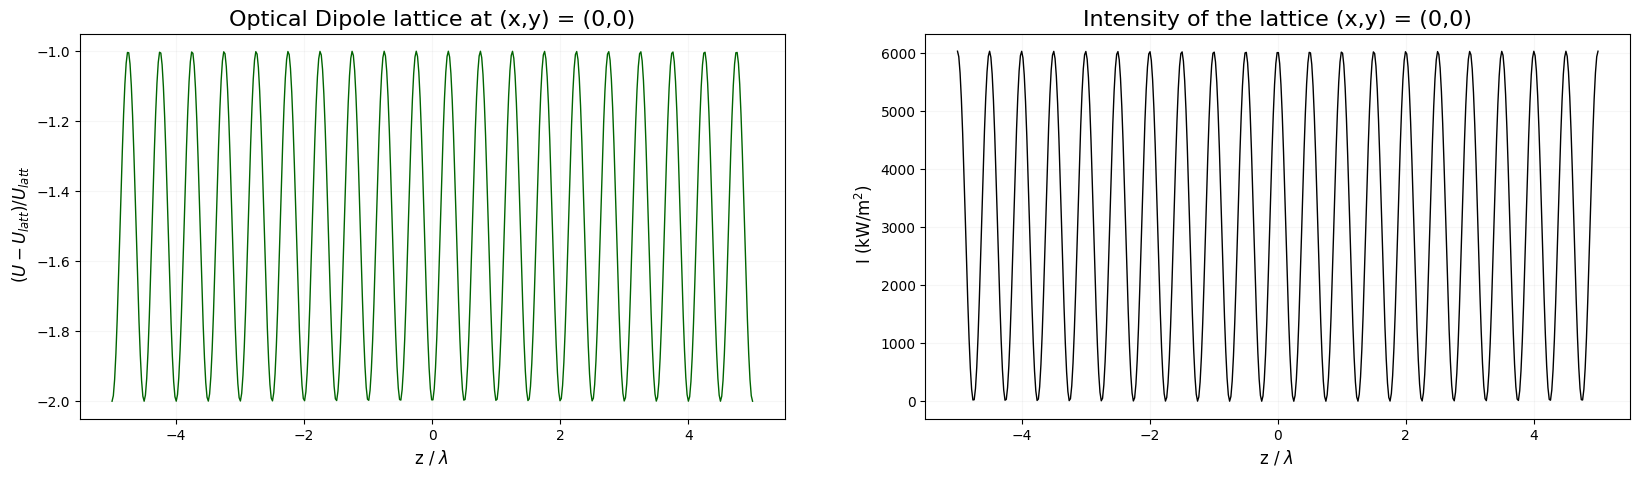

In [11]:
print('Lattice depth:', latt_depth_z, 'J')
fig, axes = plt.subplots(1, 2, figsize=(20,5))
axes[0].plot(z/wavelength, (U_0_0_z_latt-latt_depth_z)/latt_depth_z,  color='darkgreen', linewidth=1, markersize = 1)
axes[0].set_title('Optical Dipole lattice at (x,y) = (0,0)', fontsize=16)
axes[0].set_xlabel(r'z / $\lambda$ ', fontsize=12)
axes[0].set_ylabel(r' $(U-U_{latt})/U_{latt}$', fontsize=12)
#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.1)

axes[1].plot(z/wavelength, I_latt_0_0_z*1e-3, linestyle='-', color='black', linewidth=1, markersize = 3)
axes[1].set_title('Intensity of the lattice (x,y) = (0,0)', fontsize=16)
axes[1].set_xlabel(r'z / $\lambda$ ', fontsize=12)
axes[1].set_ylabel(r' I (kW/m$^2$)', fontsize=12)
#axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.1)
plt.show()

In [12]:
idx0 = np.argmin(np.abs(z-0))
idx1 = np.argmin(np.abs(z+wavelength/2))
idx2 = np.argmin(np.abs(z-wavelength/2))
idx_max_1 = np.argmax(U_0_0_z_latt[idx1:idx0]) + idx1
idx_max_2 = np.argmax(U_0_0_z_latt[idx0:idx2]) + idx0
U_single = U_0_0_z_latt[idx_max_1:idx_max_2]
z_single = z[idx_max_1:idx_max_2]

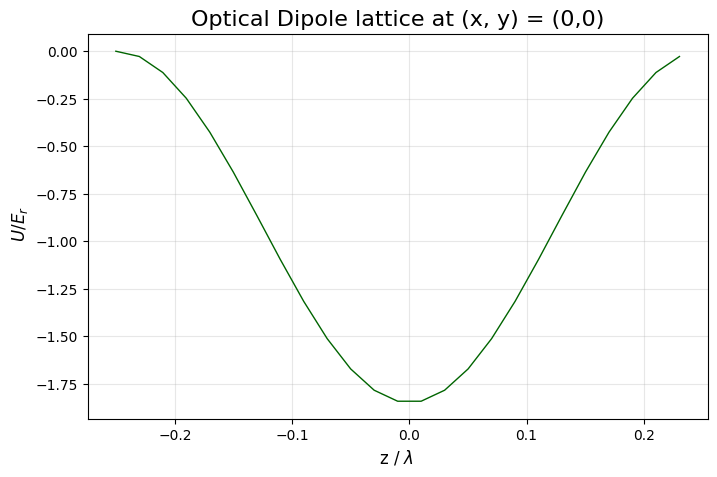

In [13]:
plt.figure(figsize=(8,5))
plt.plot(z_single/wavelength, U_single/E_r,  color='darkgreen', linewidth=1, markersize = 1)
plt.title('Optical Dipole lattice at (x, y) = (0,0)', fontsize=16)
plt.xlabel(r'z / $\lambda$ ', fontsize=12)
plt.ylabel(r' $U / E_r$', fontsize=12)
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

### x-dependence

Lattice depth: 2.054535119694237e-31 J


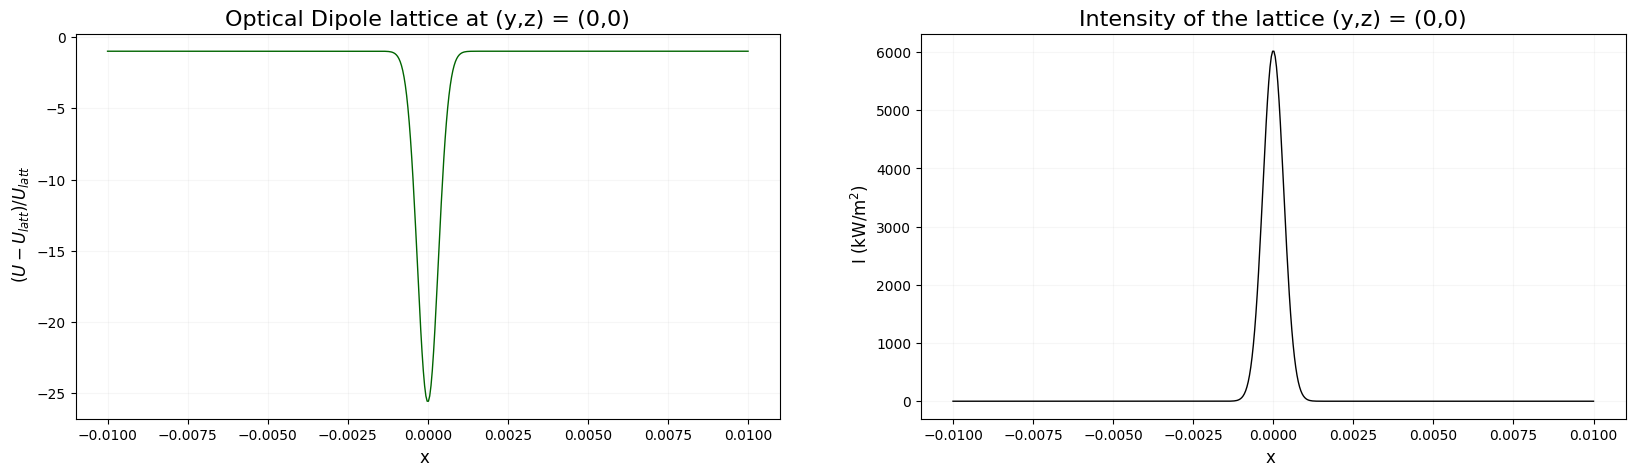

In [14]:
print('Lattice depth:', latt_depth_x, 'J')
fig, axes = plt.subplots(1, 2, figsize=(20,5))
axes[0].plot(x, (U_x_0_0_latt-latt_depth_x)/latt_depth_x,  color='darkgreen', linewidth=1, markersize = 1)
axes[0].set_title('Optical Dipole lattice at (y,z) = (0,0)', fontsize=16)
axes[0].set_xlabel(r'x ', fontsize=12)
axes[0].set_ylabel(r' $(U-U_{latt})/U_{latt}$', fontsize=12)
#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.1)

axes[1].plot(x, I_latt_x_0_0*1e-3, linestyle='-', color='black', linewidth=1, markersize = 3)
axes[1].set_title('Intensity of the lattice (y,z) = (0,0)', fontsize=16)
axes[1].set_xlabel(r'x ', fontsize=12)
axes[1].set_ylabel(r' I (kW/m$^2$)', fontsize=12)
#axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.1)
plt.show()

### y-dependence

Lattice depth: 2.054535119694237e-31 J


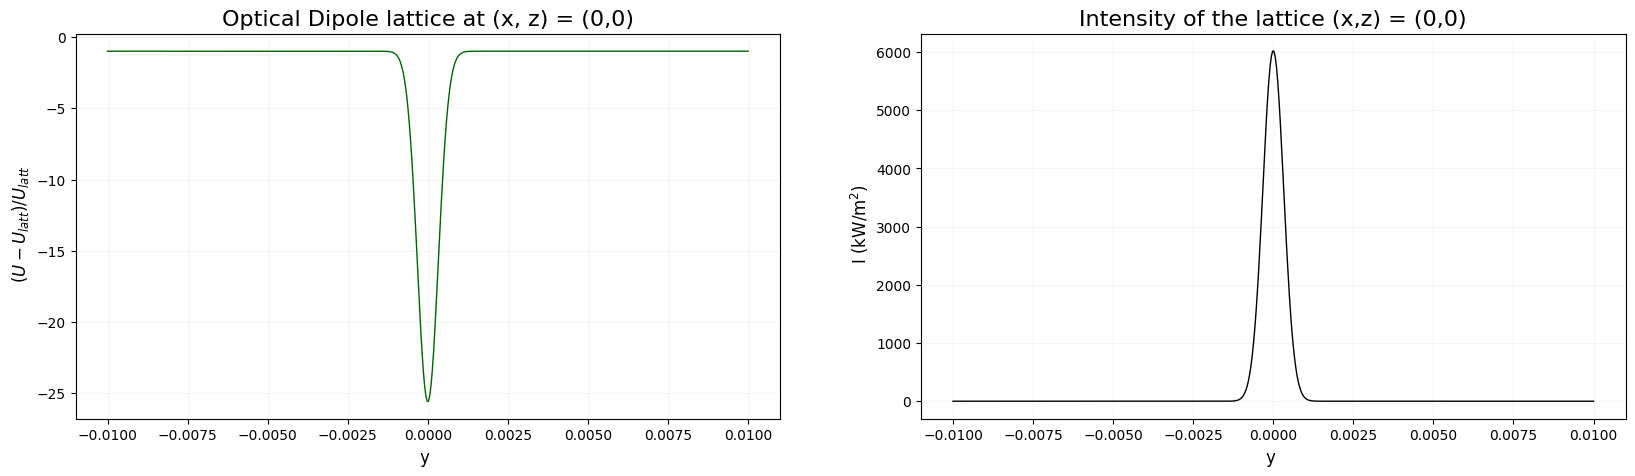

In [15]:
print('Lattice depth:', latt_depth_y, 'J')
fig, axes = plt.subplots(1, 2, figsize=(20,5))
axes[0].plot(y, (U_0_y_0_latt-latt_depth_y)/latt_depth_y,  color='darkgreen', linewidth=1, markersize = 1)
axes[0].set_title('Optical Dipole lattice at (x, z) = (0,0)', fontsize=16)
axes[0].set_xlabel(r'y ', fontsize=12)
axes[0].set_ylabel(r' $(U-U_{latt})/U_{latt}$', fontsize=12)
#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.1)

axes[1].plot(y, I_latt_0_y_0*1e-3, linestyle='-', color='black', linewidth=1, markersize = 3)
axes[1].set_title('Intensity of the lattice (x,z) = (0,0)', fontsize=16)
axes[1].set_xlabel(r'y ', fontsize=12)
axes[1].set_ylabel(r' I (kW/m$^2$)', fontsize=12)
#axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.1)
plt.show()

# Optical tweezer

In [16]:
#Parameters
Re_alpha_tw = au_to_SI(359)                                        #A^2s^4/kg ??????
P = 1                                                              #W
w0 = 650e-9                                                        #m
wavelength = 485e-9                                                #m
w1= 2*np.pi*nm_to_Hz(wavelength)                                   #Hz
#Variables
z = np.linspace(-30*wavelength, 30*wavelength, 500)                  #m
x = np.linspace(-30*wavelength, 30*wavelength, 500)                  #m
y = np.linspace(-30*wavelength, 30*wavelength, 500)                  #m

In [17]:
#U_x_y_z
U_0_0_z_tw = optical_dipole_trap_1_beam(0, 0, z, Re_alpha_tw, P, w0, wavelength, 0)                  #J
pot_depth_z = potential_depth_1_beam(Re_alpha_tw, P, w0)                                             #J

U_x_0_0_tw = optical_dipole_trap_1_beam(x, 0, 0, Re_alpha_tw, P, w0, wavelength, 0)                  #J
pot_depth_x = potential_depth_1_beam(Re_alpha_tw, P, w0)                                             #J

U_0_y_0_tw = optical_dipole_trap_1_beam(0, y, 0, Re_alpha_tw, P, w0, wavelength, 0)                  #J
pot_depth_y = potential_depth_1_beam(Re_alpha_tw, P, w0)                                             #J
#I_x_y_z
I_tw_0_0_z = gaussian_beam(0, 0, z, P, w0, wavelength, z0=0)                                         #W/m^2

I_tw_x_0_0 = gaussian_beam(x, 0, 0, P, w0, wavelength, z0=0)                                         #W/m^2

I_tw_0_y_0 = gaussian_beam(0, y, 0, P, w0, wavelength, z0=0)                                         #W/m^2

#Recoil energy
E_r = recoil_energy(m_yb, wavelength)

### z-dependence

Lattice depth: 1.68000440977578e-24 J


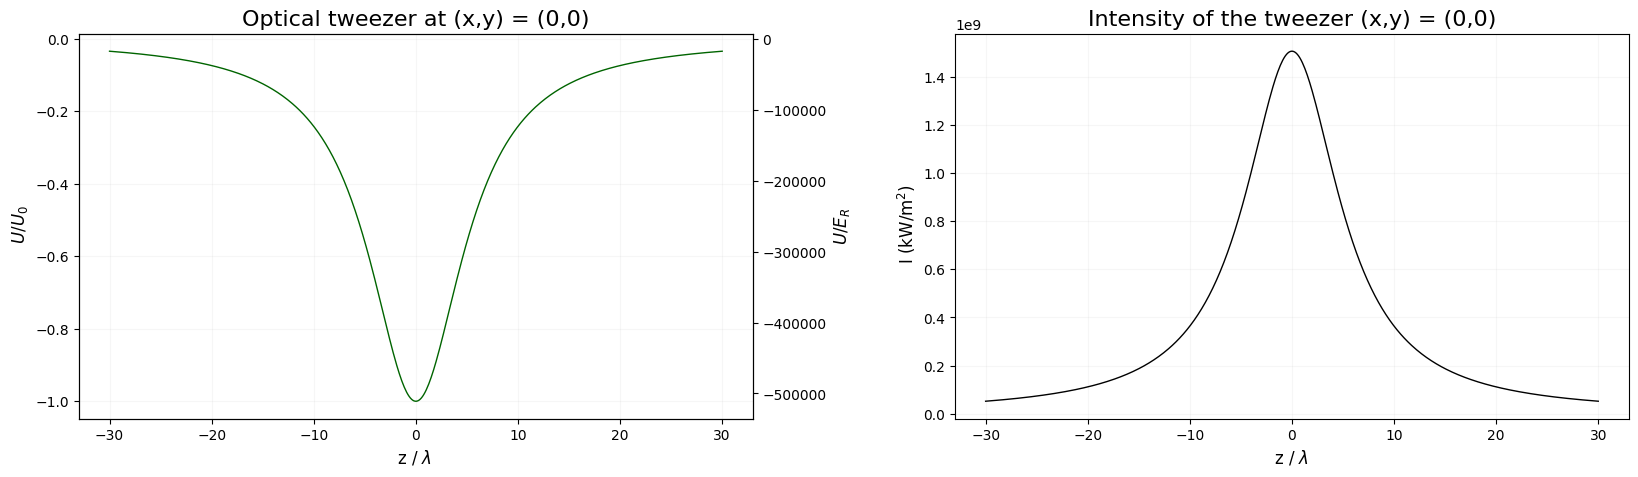

In [18]:
print('Lattice depth:', pot_depth_z, 'J')
U0_over_ER = pot_depth_z / E_r   # U0 / E_R
fig, axes = plt.subplots(1, 2, figsize=(20,5))
fig.subplots_adjust(wspace=0.3)
axes[0].plot(z/wavelength, U_0_0_z_tw/pot_depth_z,  color='darkgreen', linewidth=1, markersize = 1)
axes[0].set_title('Optical tweezer at (x,y) = (0,0)', fontsize=16)
axes[0].set_xlabel(r'z / $\lambda$ ', fontsize=12)
axes[0].set_ylabel(r' $U/U_{0}$', fontsize=12)
#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.1)

# secondary y-axis
ax2 = axes[0].twinx()
ax2.set_ylabel(r'$U/E_R$', fontsize=12)
ymin, ymax = axes[0].get_ylim()
ax2.set_ylim(ymin *U0_over_ER , ymax * U0_over_ER) #U/E_r = U/U_0*u_0/E_r

axes[1].plot(z/wavelength, I_tw_0_0_z*1e-3, linestyle='-', color='black', linewidth=1, markersize = 3)
axes[1].set_title('Intensity of the tweezer (x,y) = (0,0)', fontsize=16)
axes[1].set_xlabel(r'z / $\lambda$ ', fontsize=12)
axes[1].set_ylabel(r' I (kW/m$^2$)', fontsize=12)
#axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.1)
plt.show()

### x-dependence

Lattice depth: 1.68000440977578e-24 J


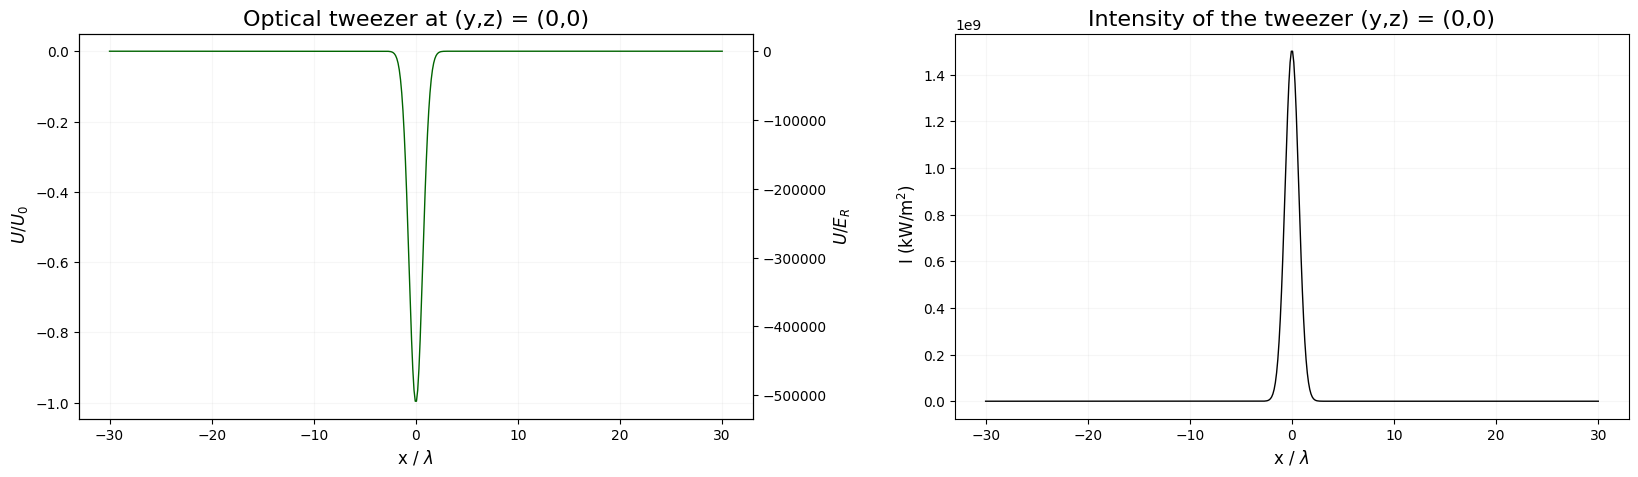

In [19]:
print('Lattice depth:', pot_depth_x, 'J')
U0_over_ER = pot_depth_x / E_r   # U0 / E_R
fig, axes = plt.subplots(1, 2, figsize=(20,5))
fig.subplots_adjust(wspace=0.3)
axes[0].plot(x/wavelength, U_x_0_0_tw/pot_depth_x,  color='darkgreen', linewidth=1, markersize = 1)
axes[0].set_title('Optical tweezer at (y,z) = (0,0)', fontsize=16)
axes[0].set_xlabel(r'x / $\lambda$ ', fontsize=12)
axes[0].set_ylabel(r' $U/U_{0}$', fontsize=12)
#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.1)

# secondary y-axis
ax2 = axes[0].twinx()
ax2.set_ylabel(r'$U/E_R$', fontsize=12)
ymin, ymax = axes[0].get_ylim()
ax2.set_ylim(ymin *U0_over_ER , ymax * U0_over_ER) #U/E_r = U/U_0*u_0/E_r

axes[1].plot(x/wavelength, I_tw_x_0_0*1e-3, linestyle='-', color='black', linewidth=1, markersize = 3)
axes[1].set_title('Intensity of the tweezer (y,z) = (0,0)', fontsize=16)
axes[1].set_xlabel(r'x / $\lambda$ ', fontsize=12)
axes[1].set_ylabel(r' I (kW/m$^2$)', fontsize=12)
#axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.1)
plt.show()

### y-dependence

Lattice depth: 1.68000440977578e-24 J


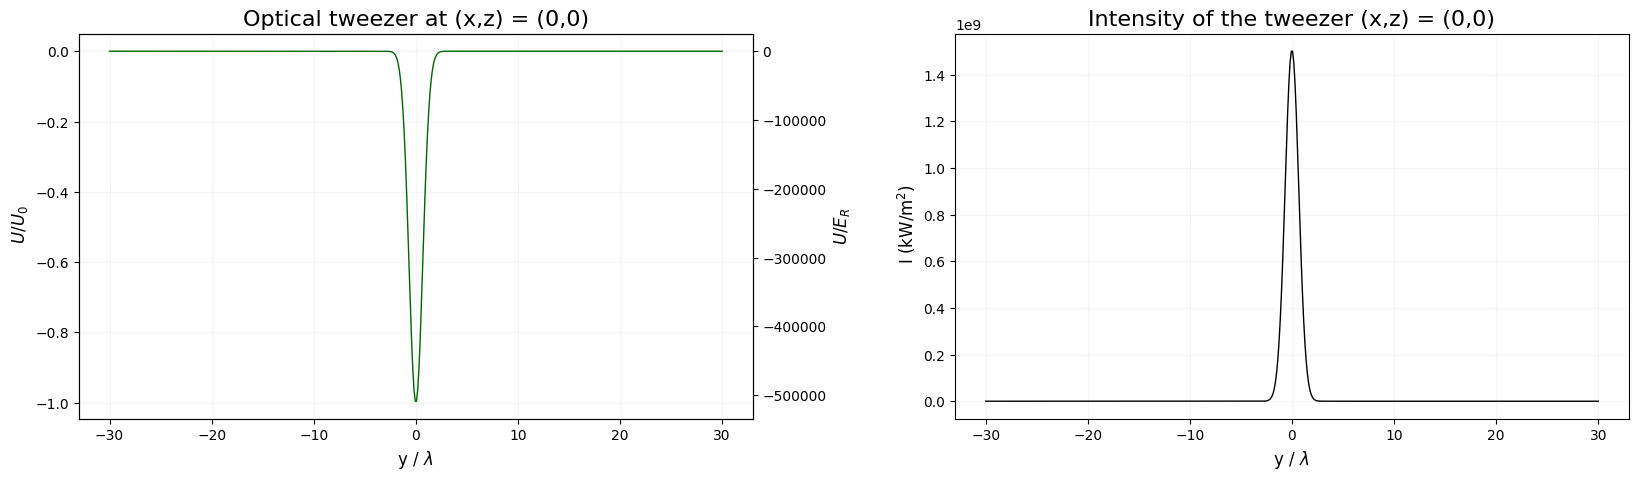

In [20]:
print('Lattice depth:', pot_depth_y, 'J')
U0_over_ER = pot_depth_y / E_r   # U0 / E_R
fig, axes = plt.subplots(1, 2, figsize=(20,5))
fig.subplots_adjust(wspace=0.3)
axes[0].plot(y/wavelength, U_0_y_0_tw/pot_depth_x,  color='darkgreen', linewidth=1, markersize = 1)
axes[0].set_title('Optical tweezer at (x,z) = (0,0)', fontsize=16)
axes[0].set_xlabel(r'y / $\lambda$ ', fontsize=12)
axes[0].set_ylabel(r' $U/U_{0}$', fontsize=12)
#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.1)

# secondary y-axis
ax2 = axes[0].twinx()
ax2.set_ylabel(r'$U/E_R$', fontsize=12)
ymin, ymax = axes[0].get_ylim()
ax2.set_ylim(ymin *U0_over_ER , ymax * U0_over_ER) #U/E_r = U/U_0*u_0/E_r

axes[1].plot(y/wavelength, I_tw_0_y_0*1e-3, linestyle='-', color='black', linewidth=1, markersize = 3)
axes[1].set_title('Intensity of the tweezer (x,z) = (0,0)', fontsize=16)
axes[1].set_xlabel(r'y / $\lambda$ ', fontsize=12)
axes[1].set_ylabel(r' I (kW/m$^2$)', fontsize=12)
#axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.1)
plt.show()

## Atom loading to optical lattice

In [21]:
# Parameters 3D MOT
N_atoms = 150
T_D = 4.4e-6                                                       #K Doppler temperature for 1S0 → 3P1 transition of Yb
max_t = 100e-6                                                     #s simulation time
t_points = np.round(max_t/5.5e-09).astype(int)                     #t evaluation points
T = 2*T_D                                                            # K
radii = 50e-6 #m 3D MOT radius
# Parameters lattice
#Parameters
Re_alpha_lat = au_to_SI(270)                                        #A^2s^4/kg
P = 1                                                               #W
w01, w02 = 50e-6, 50e-6                                             #m
z01, z02 = 0, 0                                                     #m
wavelength = 532e-9                                                 #m
w1, w2 = 2*np.pi*nm_to_Hz(wavelength), 2*np.pi*nm_to_Hz(wavelength) #Hz

z = np.linspace(-600e-6, 600e-6, 500)                               #m
y = np.linspace(-600e-6, 600e-6, 500)                               #m
x = np.linspace(-7*wavelength, 7*wavelength, 500)                   #m

### First, let us do some consistency checks

In [22]:
positions = random_points_in_sphere(radii, N_atoms)                                                             #m shape: (N_atoms, 3))
velocities = sample_mb_velocity(T, m_yb, N_atoms)                                                               #m/s shape: (N_atoms, 3))
velocities_MHz = velocities / (wavelength) * 1e-6                                                               #MHz shape: (N_atoms, 3))
v_mod = np.linalg.norm(velocities_MHz, axis=1)                                                                  #MHz shape (N_atoms,)
r_mod = np.linalg.norm(positions, axis=1)                                                                       # m shape (N_atoms,)
v_x_mod = velocities_MHz[:, 0]                                                                                   #MHz shape (N_atoms,)

U_0_y_0_latt = optical_dipole_trap_2_beams_rotated(0, y, 0, 0, Re_alpha_lat, P, w01, w02, wavelength, w1, w2)   #J
latt_depth_y = np.mean(lattice_depth_2_beams_rotated(0, y, 0, Re_alpha_lat, P, w01, w02, wavelength, 0, 0))     #J

U_0_0_z_latt = optical_dipole_trap_2_beams_rotated(0, 0, z, 0, Re_alpha_lat, P, w01, w02, wavelength, w1, w2)   #J
latt_depth_z = np.mean(lattice_depth_2_beams_rotated(0, 0, z, Re_alpha_lat, P, w01, w02, wavelength, 0, 0))     #J
U_0_latt_z = U_0_latt_2_beams_rotated(0, 0, z, Re_alpha_lat, P, w01, w02, wavelength, 0, 0)                     #J

U_x_0_0_latt = optical_dipole_trap_2_beams_rotated(x, 0, 0, 0, Re_alpha_lat, P, w01, w02, wavelength, w1, w2)   #J
latt_depth_x = lattice_depth_2_beams_rotated(x, 0, 0, Re_alpha_lat, P, w01, w02, wavelength, 0, 0)              #J
U_x_0_0_latt_MHz = J_to_Hz(U_x_0_0_latt)*1e-6                                                                   #MHz
U_0_latt_x = U_0_latt_2_beams_rotated(x, 0, 0, Re_alpha_lat, P, w01, w02, wavelength, 0, 0)                     #J

U_grav =(m_yb*g*x)                                                                                              #J

#gradients
I_x = gaussian_beam_rotated(x, 0, 0, P, w01, wavelength, z0=0) 
grad_I_x = np.array([grad_I_rotated(x_, 0, 0, P, w01, wavelength, 0) for x_ in x])
grad_U_x = np.array([grad_U_L_rotated(x_, 0, 0, Re_alpha_lat, P, w01, w02, wavelength, 0, 0) for x_ in x]) 

I_y = gaussian_beam_rotated(0, y, 0, P, w01, wavelength, z0=0) 
grad_I_y = np.array([grad_I_rotated(0, y_, 0, P, w01, wavelength, 0) for y_ in y])
grad_U_y = np.array([grad_U_L_rotated(0, y_, 0, Re_alpha_lat, P, w01, w02, wavelength, 0, 0) for y_ in y]) 

I_z = gaussian_beam_rotated(0, 0, z, P, w01, wavelength, z0=0) 
grad_I_z = np.array([grad_I_rotated(0, 0, z_, P, w01, wavelength, 0) for z_ in z])
grad_U_z = np.array([grad_U_L_rotated(0, 0, z_, Re_alpha_lat, P, w01, w02, wavelength, 0, 0) for z_ in z]) 

In [23]:
"""x = np.linspace(-radii, radii, 100)
y = np.linspace(-radii, radii, 100)
z = np.linspace(-radii, radii, 100)
grad = grad_U_L_rotated_(x, y, z, Re_alpha_lat, P, w01, w02, wavelength, 0,0)
for i in range(100):
    if np.isnan(grad[:, i]).any() or np.isinf(grad[:, i]).any():
        print(grad[:,i])"""


'x = np.linspace(-radii, radii, 100)\ny = np.linspace(-radii, radii, 100)\nz = np.linspace(-radii, radii, 100)\ngrad = grad_U_L_rotated_(x, y, z, Re_alpha_lat, P, w01, w02, wavelength, 0,0)\nfor i in range(100):\n    if np.isnan(grad[:, i]).any() or np.isinf(grad[:, i]).any():\n        print(grad[:,i])'

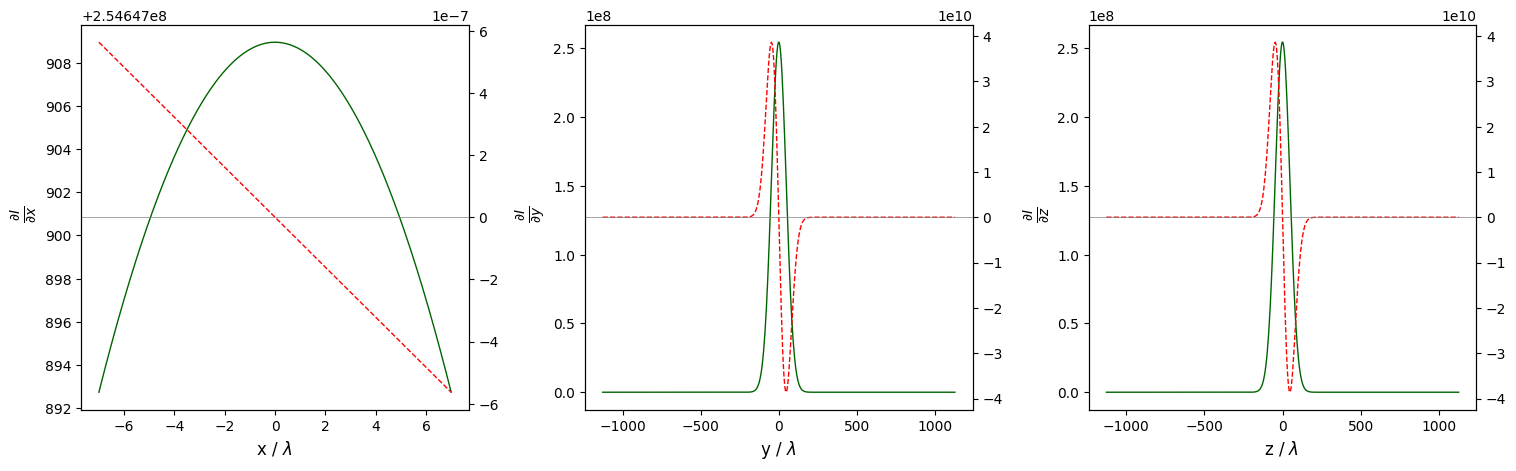

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
plt.subplots_adjust(wspace=0.3)

ax0 = axes[0].twinx()
ax0.plot(x/wavelength, grad_I_x[:,0],  color='red', linewidth=1, markersize = 1, linestyle ='--')
ax0.axhline(0, color='gray', linestyle='-', linewidth=0.5)
axes[0].plot(x/wavelength, I_x,  color='darkgreen', linewidth=1, markersize = 1)
#axes[0].set_title('x', fontsize=16)
axes[0].set_xlabel(r'x / $\lambda$ ', fontsize=12)
axes[0].set_ylabel(r' $\frac{\partial I}{\partial x}$', fontsize=14)

ax1 = axes[1].twinx()
ax1.plot(y/wavelength, grad_I_y[:,1],  color='red', linewidth=1, markersize = 1, linestyle ='--')
ax1.axhline(0, color='gray', linestyle='-', linewidth=0.5)
axes[1].plot(y/wavelength, I_y,  color='darkgreen', linewidth=1, markersize = 1)
#axes[1].set_title('y', fontsize=16)
axes[1].set_xlabel(r'y / $\lambda$ ', fontsize=12)
axes[1].set_ylabel(r' $\frac{\partial I}{\partial y}$', fontsize=14)

ax2 = axes[2].twinx()
ax2.plot(z/wavelength, grad_I_z[:,2],  color='red', linewidth=1, markersize = 1, linestyle ='--')
ax2.axhline(0, color='gray', linestyle='-', linewidth=0.5)
axes[2].plot(z/wavelength, I_z,  color='darkgreen', linewidth=1, markersize = 1)
#axes[2].set_title('z', fontsize=16)
axes[2].set_xlabel(r'z / $\lambda$ ', fontsize=12)
axes[2].set_ylabel(r' $\frac{\partial I}{\partial z}$', fontsize=14)
#axes.set_legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)


plt.show()

Text(0, 0.5, ' $\\frac{\\partial u}{\\partial x}$')

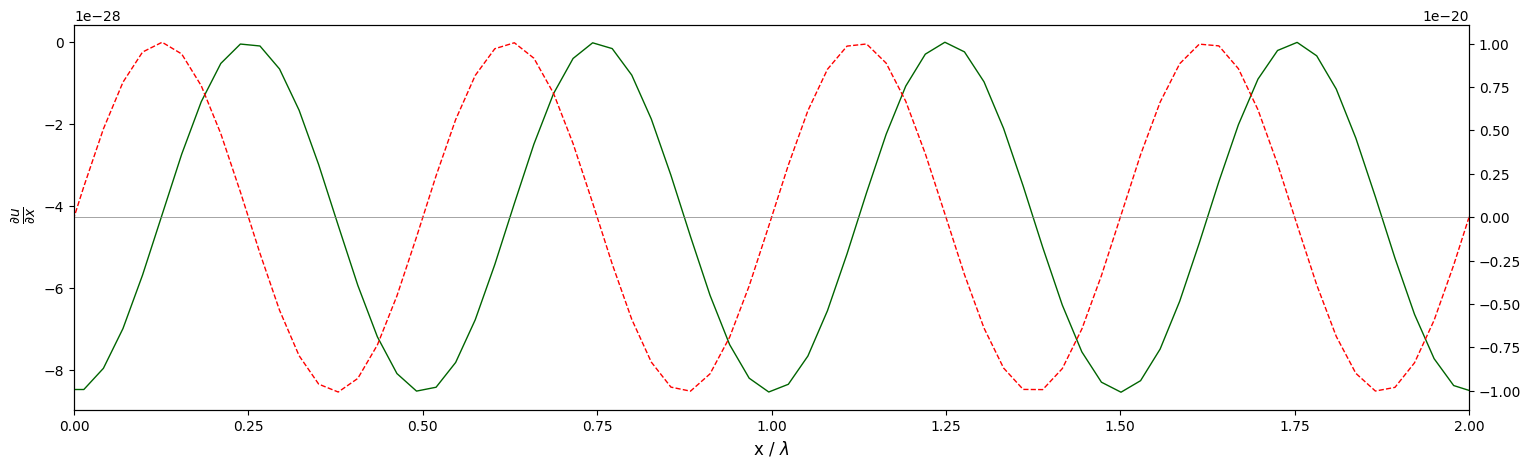

In [25]:
fig, axes = plt.subplots(1, 1, figsize=(18,5))

ax0 = axes.twinx()
ax0.plot(x/wavelength, grad_U_x[:,0],  color='red', linewidth=1, markersize = 1, linestyle ='--')
ax0.axhline(0, color='gray', linestyle='-', linewidth=0.5)

axes.plot(x/wavelength, U_x_0_0_latt,  color='darkgreen', linewidth=1, markersize = 1)
axes.set_xlim(0,2)
axes.set_xlabel(r'x / $\lambda$ ', fontsize=12)
axes.set_ylabel(r' $\frac{\partial u}{\partial x}$', fontsize=14)


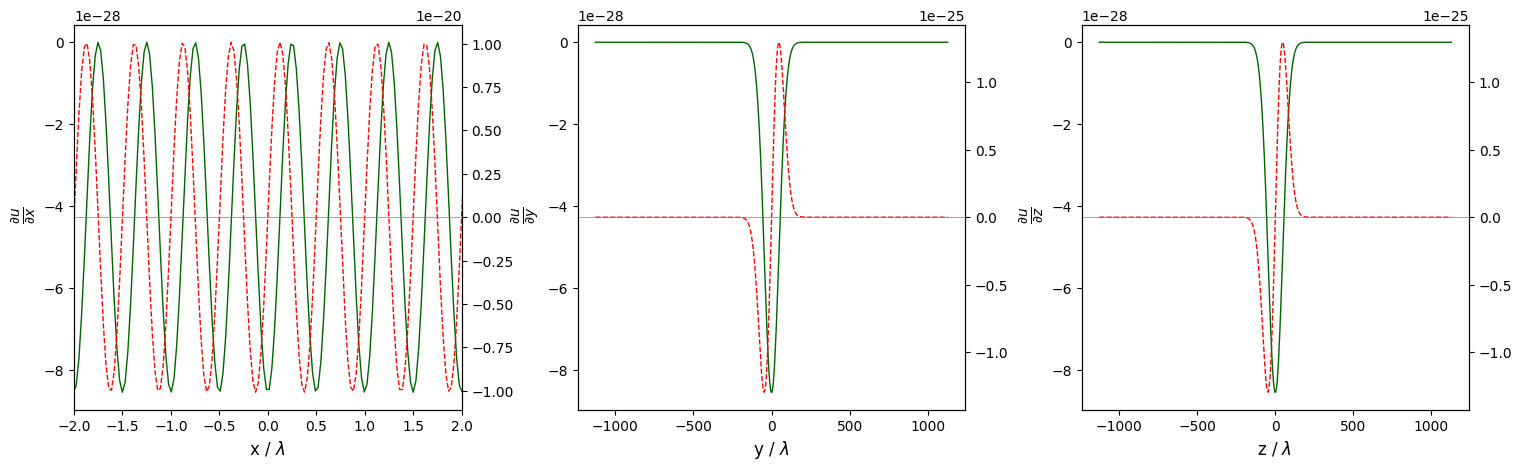

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
plt.subplots_adjust(wspace=0.3)

ax0 = axes[0].twinx()
ax0.plot(x/wavelength, grad_U_x[:,0],  color='red', linewidth=1, markersize = 1, linestyle ='--')
ax0.axhline(0, color='gray', linestyle='-', linewidth=0.5)

axes[0].plot(x/wavelength, U_x_0_0_latt,  color='darkgreen', linewidth=1, markersize = 1)
axes[0].set_xlim(-2,2)
#axes[0].set_title('x', fontsize=16)
axes[0].set_xlabel(r'x / $\lambda$ ', fontsize=12)
axes[0].set_ylabel(r' $\frac{\partial u}{\partial x}$', fontsize=14)

ax1 = axes[1].twinx()
ax1.plot(y/wavelength, grad_U_y[:,1],  color='red', linewidth=1, markersize = 1, linestyle ='--')
ax1.axhline(0, color='gray', linestyle='-', linewidth=0.5)

axes[1].plot(y/wavelength, U_0_y_0_latt,  color='darkgreen', linewidth=1, markersize = 1)
#axes[1].set_title('y', fontsize=16)
axes[1].set_xlabel(r'y / $\lambda$ ', fontsize=12)
axes[1].set_ylabel(r' $\frac{\partial u}{\partial y}$', fontsize=14)

ax2 = axes[2].twinx()
ax2.plot(z/wavelength, grad_U_z[:,2],  color='red', linewidth=1, markersize = 1, linestyle ='--')
ax2.axhline(0, color='gray', linestyle='-', linewidth=0.5)

axes[2].plot(z/wavelength, U_0_0_z_latt,  color='darkgreen', linewidth=1, markersize = 1)
#axes[2].set_title('z', fontsize=16)
axes[2].set_xlabel(r'z / $\lambda$ ', fontsize=12)
axes[2].set_ylabel(r' $\frac{\partial u}{\partial z}$', fontsize=14)
#axes.set_legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)


plt.show()

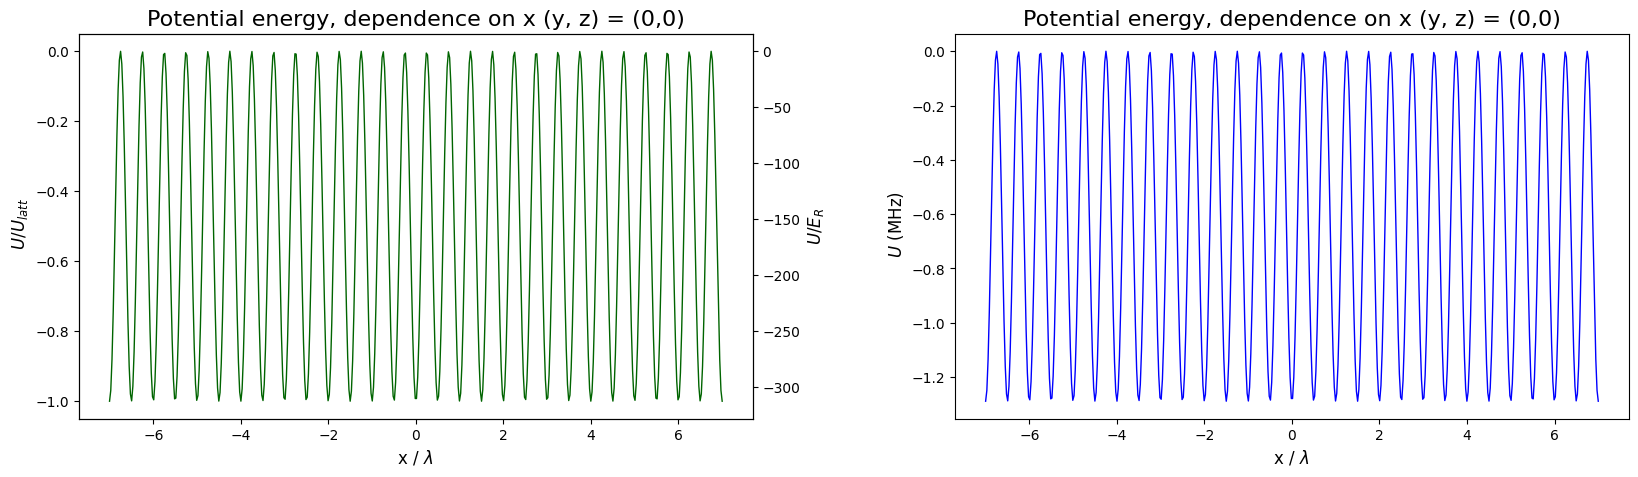

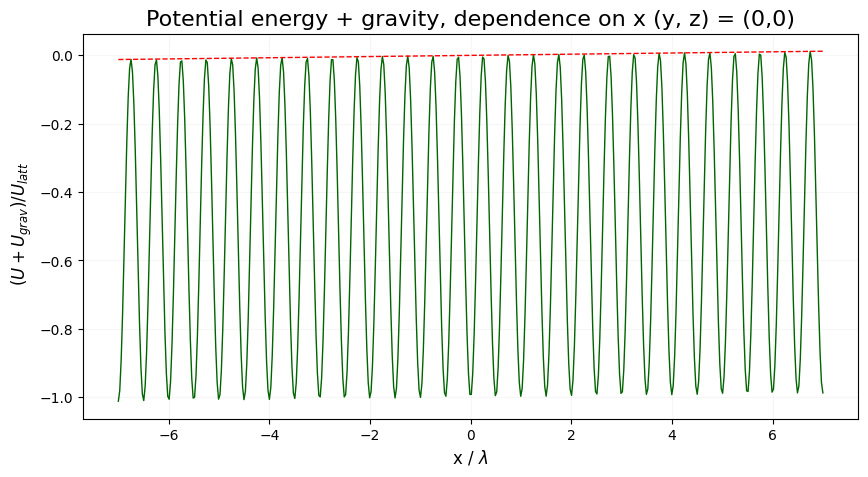

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))
plt.subplots_adjust(wspace=0.3)

axes1 = axes[0]
axes1.plot(x/wavelength, U_x_0_0_latt/latt_depth_x,  color='darkgreen', linewidth=1, markersize = 1)
axes1.set_title('Potential energy, dependence on x (y, z) = (0,0)', fontsize=16)
axes1.set_xlabel(r'x / $\lambda$ ', fontsize=12)
axes1.set_ylabel(r' $U/U_{latt}$', fontsize=12)

# secondary y-axis
E_r = recoil_energy(m_yb, wavelength)
latt_depth_x_over_ER = np.mean(latt_depth_x) / E_r   # U_latt / E_R
ax2 = axes1.twinx()
ax2.set_ylabel(r'$U/E_R$', fontsize=12)
ymin, ymax = axes1.get_ylim()
ax2.set_ylim(ymin *latt_depth_x_over_ER , ymax * latt_depth_x_over_ER) #U/E_r = U/U_0*u_0/E_r
#axes.set_legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
#axes1.grid(True, alpha=0.1)

axes2 = axes[1]
axes2.plot(x/wavelength, U_x_0_0_latt_MHz,  color='blue', linewidth=1, markersize = 1)
axes2.set_title('Potential energy, dependence on x (y, z) = (0,0)', fontsize=16)
axes2.set_xlabel(r'x / $\lambda$ ', fontsize=12)
axes2.set_ylabel(r' $U$ (MHz)', fontsize=12)

fig, axes = plt.subplots(1, 1, figsize=(10,5))
axes.plot(x/wavelength, (U_x_0_0_latt+U_grav)/latt_depth_x,  color='darkgreen', linewidth=1, markersize = 1)
axes.plot(x/wavelength, U_grav/latt_depth_x,  color='red', linewidth=1, markersize = 1, linestyle='--')
axes.set_title('Potential energy + gravity, dependence on x (y, z) = (0,0)', fontsize=16)
axes.set_xlabel(r'x / $\lambda$ ', fontsize=12)
axes.set_ylabel(r' $(U+U_{grav})/U_{latt}$', fontsize=12)
#axes.set_legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes.grid(True, alpha=0.1)

plt.show()


### Since the effect of the gravity is small, we are going to neglect it

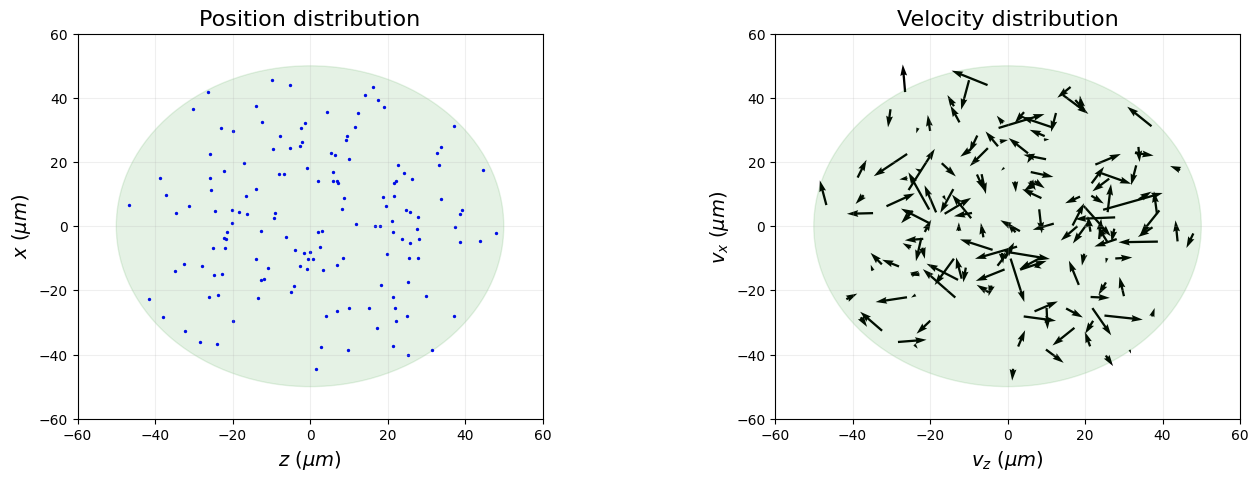

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# ---- LEFT PLOT ----
ax = axes[0]
#ax3 = ax.twiny()
ax.scatter(positions[:,2]*1e6, positions[:,0]*1e6, s=2, color='b')

circle = plt.Circle((0,0), radii*1e6, color='green', fill=True, linewidth=1, alpha=0.1, label='3D MOT')
ax.add_patch(circle)

#ax3.plot((U_x_0_0_latt)/latt_depth_x, x*1e6, color='black', linewidth=1, label='Potential')

#ax3.set_xlabel(r'$U/U_{latt}$', fontsize=14)
#ax3.set_ylim()


ax.set_xlim(-60,60)
ax.set_ylim(-60,60)
ax.set_xlabel(r'$z$ ($\mu m$)', fontsize=14)
ax.set_ylabel(r'$x$ ($\mu m$)', fontsize=14)
ax.set_title('Position distribution', fontsize=16)
ax.grid(True, alpha=0.2)


# ---- RIGHT PLOT (example: histogram of x positions) ----
ax2 = axes[1]


ax2.quiver(positions[:,2]*1e6, positions[:,0]*1e6, velocities[:,2]*1e6, velocities[:,0]*1e6, angles='xy', scale_units='xy')

circle = plt.Circle((0,0), radii*1e6, color='green', fill=True, linewidth=1, alpha=0.1, label='3D MOT')
ax2.add_patch(circle)

ax2.set_xlim(-60, 60)
ax2.set_ylim(-60, 60)
ax2.set_xlabel(r'$v_z$ ($\mu m$)', fontsize=14)
ax2.set_ylabel(r'$v_x$ ($\mu m$)', fontsize=14)
ax2.set_title('Velocity distribution', fontsize=16)
ax2.grid(True, alpha=0.2)

fig.subplots_adjust(wspace=0.5)   # <-- adjust this value
plt.show()

In [29]:
len(positions[:, 0]/wavelength), len(v_x_mod,)

(150, 150)

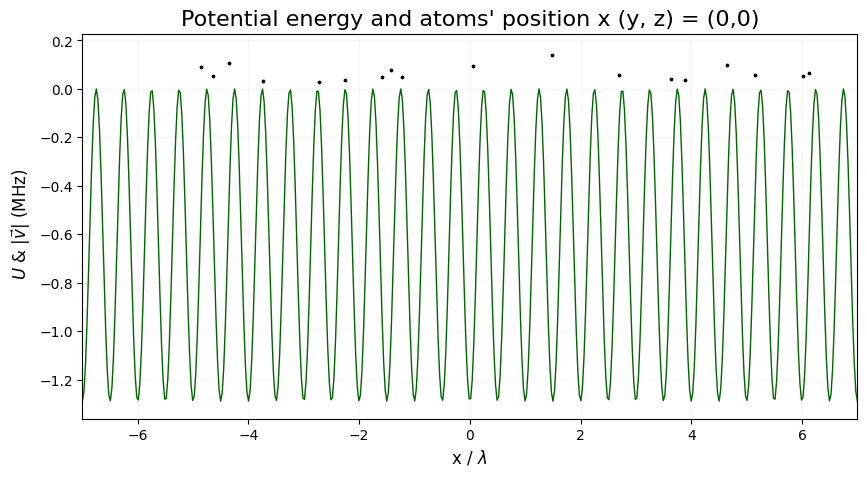

In [30]:
fig, axes = plt.subplots(1, 1, figsize=(10,5))
axes.plot(x/wavelength, U_x_0_0_latt_MHz,  color='darkgreen', linewidth=1, markersize = 1)
axes.scatter(positions[:,2]/wavelength, v_mod, s=3, color='black')

axes.set_title('Potential energy and atoms\' position x (y, z) = (0,0)', fontsize=16)
axes.set_xlabel(r'x / $\lambda$ ', fontsize=12)
axes.set_ylabel(r' $U$ & $|\vec{v}|$ (MHz)', fontsize=12)
axes.set_xlim(min(x/wavelength), max(x/wavelength))
#axes.set_legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes.grid(True, alpha=0.1)

plt.show()

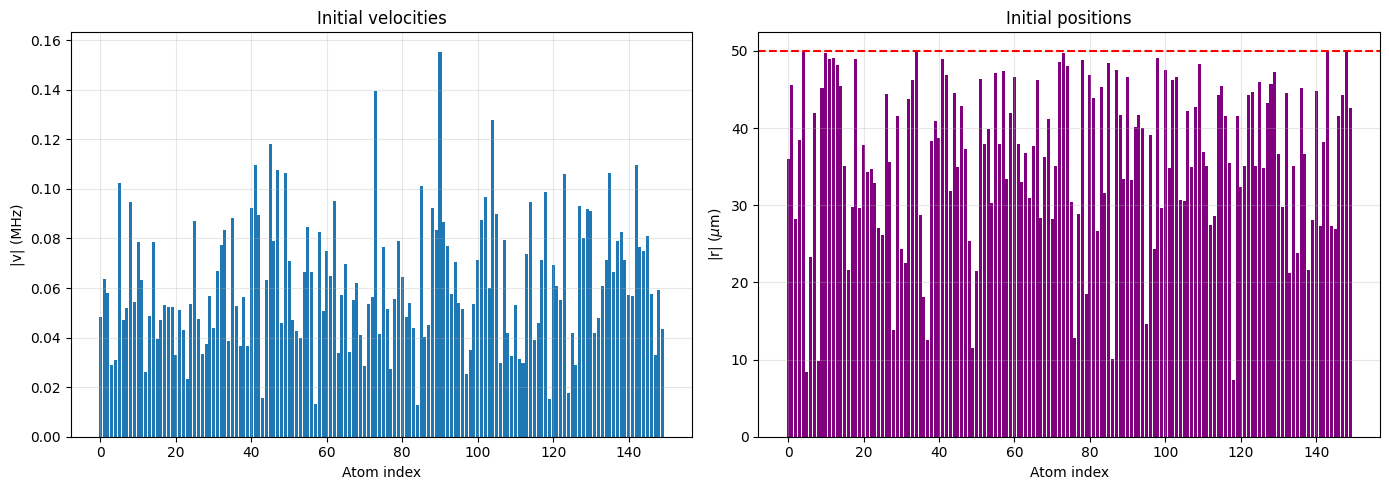

In [31]:
atoms = np.arange(N_atoms)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

v_mod = np.linalg.norm(velocities_MHz, axis=1)
axes[0].bar(atoms, v_mod)
axes[0].set_xlabel('Atom index')
axes[0].set_ylabel('|v| (MHz)')
axes[0].set_title('Initial velocities')
axes[0].grid(alpha=0.3)

r_mod = np.linalg.norm(positions*1e6, axis=1)
axes[1].bar(atoms, r_mod, color='purple')
axes[1].axhline(radii*1e6, color='red', linestyle='--', label='3D MOT radius')
axes[1].set_xlabel('Atom index')
axes[1].set_ylabel(r'|r| ($\mu$m)')
axes[1].set_title('Initial positions')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
"""
np.random.seed(10)
N_atoms = 10
init_pos = random_points_in_sphere(radii, N_atoms)                 # Positions of each atoms over time                       [shape: (N_atoms, 3)]
init_vel = sample_mb_velocity(T, m_yb, N_atoms)                    # Velocities of each atom over time                       [shape: (N_atoms, 3)]
init_vec = np.hstack((init_pos, init_vel))
args = [Re_alpha_lat, P, w01, w02, wavelength, 0, 0]
max_t = 1
positions =[]
velocities = []

for i in range(N_atoms):
    sol = solve_ivp(f_lattice, [0,max_t], init_vec[i], method= 'DOP853', t_eval=np.linspace(0, max_t, 100), args=args)
    print('solution found')
    times = sol.t
    vec=sol.y
    positions.append(np.array([vec[0], vec[1], vec[2]]))
    velocities.append(np.array([vec[3], vec[4], vec[5]]))
vec
"""

"\nnp.random.seed(10)\nN_atoms = 10\ninit_pos = random_points_in_sphere(radii, N_atoms)                 # Positions of each atoms over time                       [shape: (N_atoms, 3)]\ninit_vel = sample_mb_velocity(T, m_yb, N_atoms)                    # Velocities of each atom over time                       [shape: (N_atoms, 3)]\ninit_vec = np.hstack((init_pos, init_vel))\nargs = [Re_alpha_lat, P, w01, w02, wavelength, 0, 0]\nmax_t = 1\npositions =[]\nvelocities = []\n\nfor i in range(N_atoms):\n    sol = solve_ivp(f_lattice, [0,max_t], init_vec[i], method= 'DOP853', t_eval=np.linspace(0, max_t, 100), args=args)\n    print('solution found')\n    times = sol.t\n    vec=sol.y\n    positions.append(np.array([vec[0], vec[1], vec[2]]))\n    velocities.append(np.array([vec[3], vec[4], vec[5]]))\nvec\n"

In [33]:
#N_atoms = 30
t, vels_overtime, pos_overtime, energies_overtime, idx_lost_atoms = atom_loading_MOT_lattice(max_t, t_points, Re_alpha_lat, P, w01, w02, wavelength, z01, z02, radii, N_atoms, T)
#t, vels_overtime, pos_overtime, energies_overtime, idx_lost_atoms = atom_loading_MOT_lattice_odeint(0.1, Re_alpha_lat, P, w01, w02, wavelength, 0, 0, radii, N_atoms, T)

100%|██████████| 150/150 [00:09<00:00, 16.42it/s]


In [34]:
t_eval=np.linspace(0, max_t, t_points)
dt = t_eval[1]-t_eval[0]
dt

np.float64(5.500247511138002e-09)

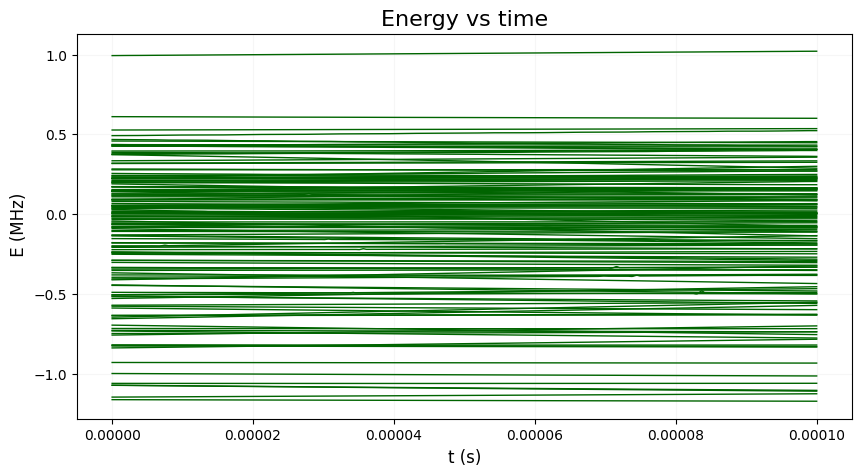

In [35]:
fig, axes = plt.subplots(1, 1, figsize=(10,5))
fig.subplots_adjust(wspace=0.3)
for i in range(N_atoms):
    axes.plot(t, J_to_Hz(energies_overtime[i])*1e-6, color='darkgreen', linewidth=1, markersize = 1)
#axes.axvline(t_eval[0], color='red', linestyle='--', linewidth = 1)
#axes.axvline(t_eval[1], color='red', linestyle='--', label='step size', linewidth = 1)
axes.set_title('Energy vs time', fontsize=16)
axes.set_xlabel(r't (s)', fontsize=12)
axes.set_ylabel(r' E (MHz)', fontsize=12)
#axes.set_xlim(-1e-3, 0.002)
#axes.set_ylim(-1, 0.5)
#axes.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes.grid(True, alpha=0.1)

plt.show()

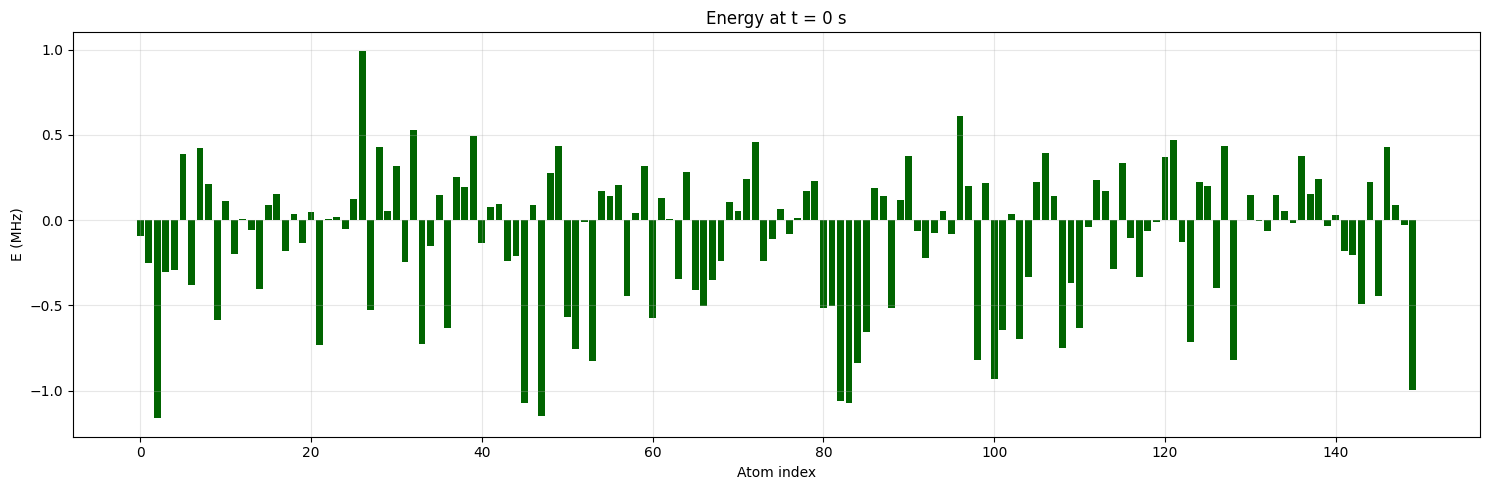

In [36]:
fig, axes = plt.subplots(1, 1, figsize=(15, 5))

atoms = np.arange(N_atoms)
axes.bar(atoms, J_to_Hz(energies_overtime[:,0])*1e-6, color='darkgreen')
axes.set_xlabel('Atom index')
axes.set_ylabel('E (MHz)')
axes.set_title('Energy at t = 0 s')
axes.grid(alpha=0.3)


plt.tight_layout()
plt.show()

In [37]:
vx, vy, vz = vels_overtime[:, 0, :], vels_overtime[:, 1, :], vels_overtime[:, 2, :]
x, y, z = pos_overtime[:, 0, :], pos_overtime[:, 1, :], pos_overtime[:, 2, :]
print('Number of lost atoms:', len(idx_lost_atoms))
print('Trapped atoms fraction:', (N_atoms-len(idx_lost_atoms))/N_atoms)

Number of lost atoms: 75
Trapped atoms fraction: 0.5


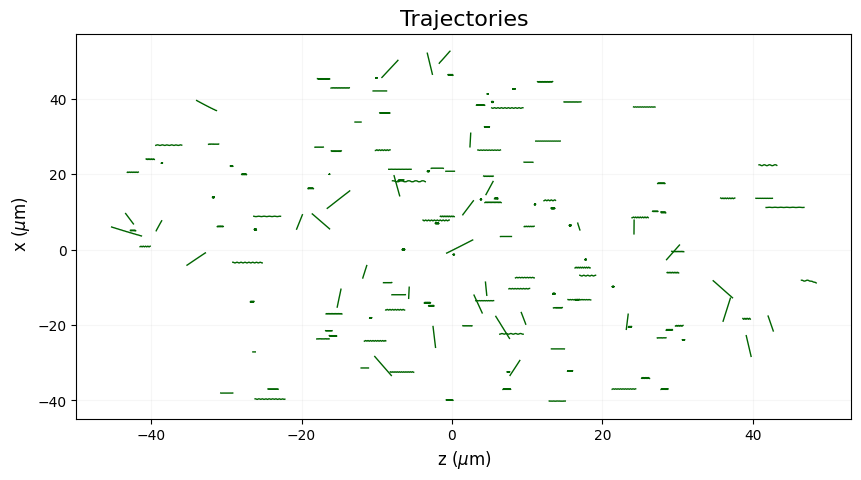

In [38]:
fig, axes = plt.subplots(1, 1, figsize=(10,5))
fig.subplots_adjust(wspace=0.3)
for i in range(N_atoms):
    axes.plot(z[i]*1e6, x[i]*1e6, color='darkgreen', linewidth=1, markersize = 1)

axes.set_title('Trajectories', fontsize=16)
axes.set_xlabel(r'z ($\mu$m)', fontsize=12)
axes.set_ylabel(r' x ($\mu$m)', fontsize=12)
#axes.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes.grid(True, alpha=0.1)

plt.show()

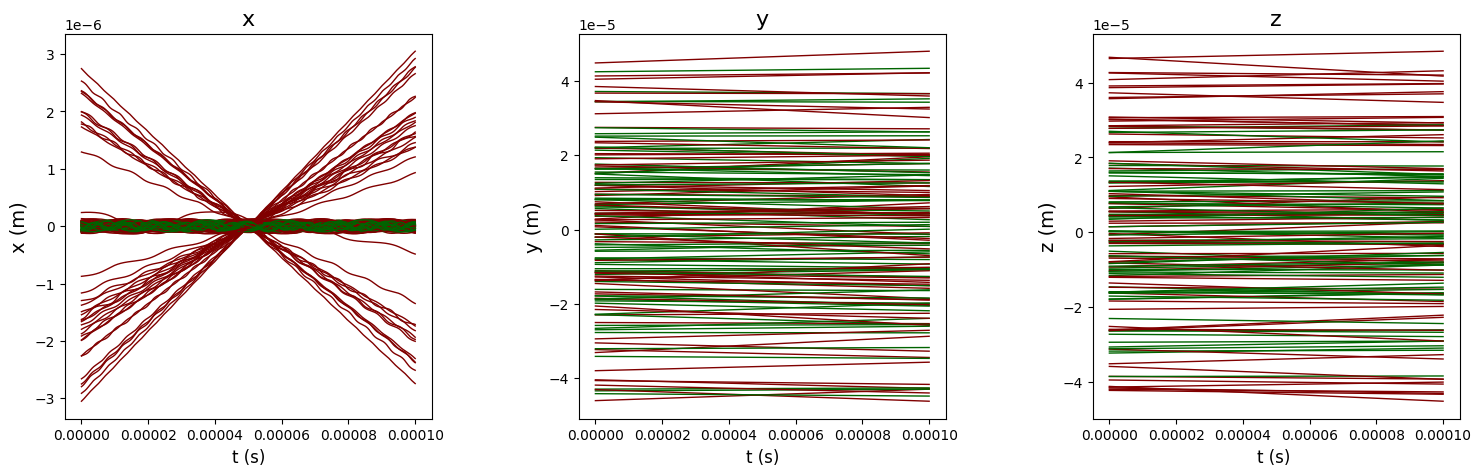

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
plt.subplots_adjust(wspace=0.4)

for i in range(len(x)):
    if i not in idx_lost_atoms:
        axes[0].plot(t, x[i]-np.mean(x[i]),   linewidth=1, markersize = 1, color = 'darkgreen')
    else:
        axes[0].plot(t, x[i]-np.mean(x[i]),   linewidth=1, markersize = 1, color = 'maroon')

    axes[0].set_title('x', fontsize=16)
    axes[0].set_xlabel(r't (s)', fontsize=12)
    axes[0].set_ylabel(r'x (m)', fontsize=14)
    #axes[0].set_xlim(0,0.0001)
    if i not in idx_lost_atoms:
        axes[1].plot(t, y[i],  linewidth=1, markersize = 1, color = 'darkgreen')
    else: 
        axes[1].plot(t, y[i],  linewidth=1, markersize = 1, color = 'maroon')
    axes[1].set_title('y', fontsize=16)
    axes[1].set_xlabel(r't (s)', fontsize=12)
    axes[1].set_ylabel(r'y (m)', fontsize=14)
    if i not in idx_lost_atoms:
        axes[2].plot(t, z[i],  linewidth=1, markersize = 1, color = 'darkgreen')
    else:
        axes[2].plot(t, z[i],  linewidth=1, markersize = 1, color = 'maroon')
    axes[2].set_title('z', fontsize=16)
    axes[2].set_xlabel(r't (s) ', fontsize=12)
    axes[2].set_ylabel(r'z (m)', fontsize=14)
#for i in range(3):
    #axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.show()

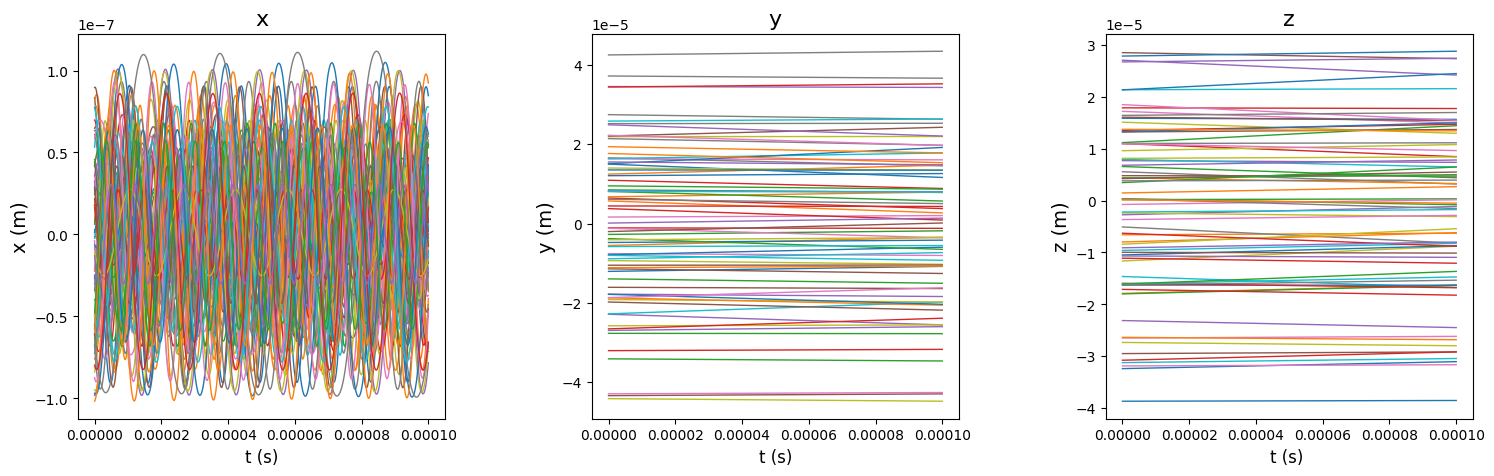

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
plt.subplots_adjust(wspace=0.4)

for i in range(len(x)):
    if i not in idx_lost_atoms:
        axes[0].plot(t, x[i]-np.mean(x[i]),   linewidth=1, markersize = 1, label = f'atom {i}')
        axes[1].plot(t, y[i],  linewidth=1, markersize = 1, label = f'atom {i}')
        axes[2].plot(t, z[i],  linewidth=1, markersize = 1, label = f'atom {i}')
    axes[0].set_title('x', fontsize=16)
    axes[0].set_xlabel(r't (s)', fontsize=12)
    axes[0].set_ylabel(r'x (m)', fontsize=14)
    #axes[0].set_xlim(0,0.0001)

    axes[1].set_title('y', fontsize=16)
    axes[1].set_xlabel(r't (s)', fontsize=12)
    axes[1].set_ylabel(r'y (m)', fontsize=14)

    axes[2].set_title('z', fontsize=16)
    axes[2].set_xlabel(r't (s) ', fontsize=12)
    axes[2].set_ylabel(r'z (m)', fontsize=14)
#for i in range(3):
    #axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.show()

In [41]:
idx_not_lost = [i for i in range(N_atoms) if i not in idx_lost_atoms]

x_trap, y_trap , z_trap = x[idx_not_lost], y[idx_not_lost], z[idx_not_lost]
vx_trap, vy_trap , vz_trap = vx[idx_not_lost], vy[idx_not_lost], vz[idx_not_lost]

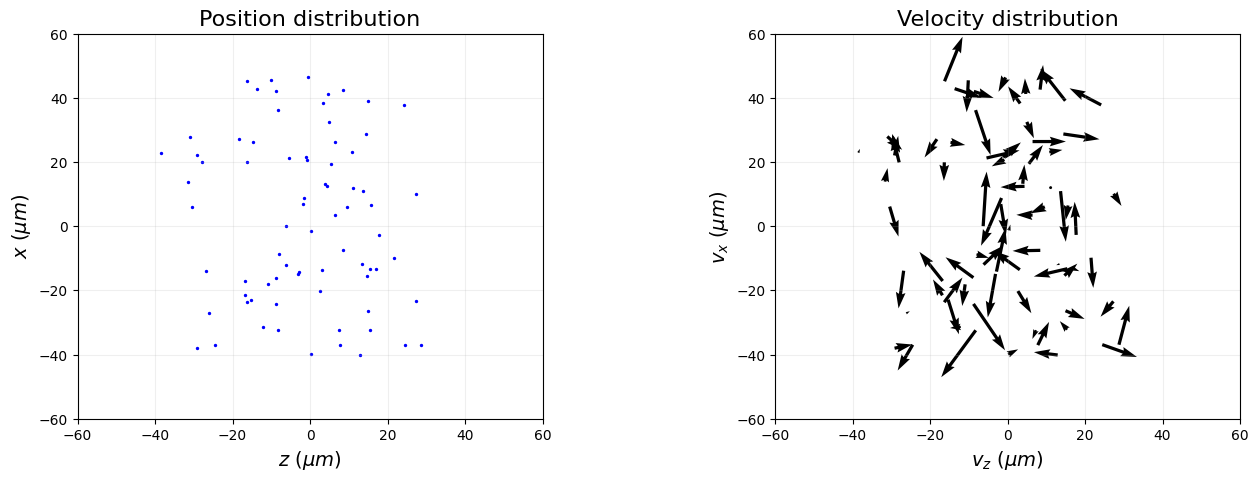

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# ---- LEFT PLOT ----
ax = axes[0]
#ax3 = ax.twiny()
ax.scatter(z_trap[:,-1]*1e6, x_trap[:,-1]*1e6, s=2, color='b')

ax.set_xlim(-60,60)
ax.set_ylim(-60,60)
ax.set_xlabel(r'$z$ ($\mu m$)', fontsize=14)
ax.set_ylabel(r'$x$ ($\mu m$)', fontsize=14)
ax.set_title('Position distribution', fontsize=16)
ax.grid(True, alpha=0.2)


# ---- RIGHT PLOT (example: histogram of x positions) ----
ax2 = axes[1]

ax2.quiver(z_trap[:,-1]*1e6, x_trap[:,-1]*1e6, vz_trap[:,-1]*1e6, vx_trap[:,-1]*1e6, angles='xy', scale_units='xy')

ax2.set_xlim(-60, 60)
ax2.set_ylim(-60, 60)
ax2.set_xlabel(r'$v_z$ ($\mu m$)', fontsize=14)
ax2.set_ylabel(r'$v_x$ ($\mu m$)', fontsize=14)
ax2.set_title('Velocity distribution', fontsize=16)
ax2.grid(True, alpha=0.2)

fig.subplots_adjust(wspace=0.5)   # <-- adjust this value
plt.show()

In [43]:
#Store all the data and results
inputs = {
    "N_atoms": N_atoms,
    "doppler_temperature": T_D,
    "max_t": max_t,
    "t_points": t_points,
    "temperature": T,
    "mot_radius": radii,
    "polarizability": Re_alpha_lat,
    "laser_power": P,
    "beam_waist": [w01, w02],
    "beam_positions": [z01, z02],
    "wavelength": wavelength,
    "frequencies": [w1, w2]
}

results = {
    "time": t,
    "velocities": vels_overtime,
    "positions": pos_overtime,
    "energies": energies_overtime,
    "lost_atoms": idx_lost_atoms
}

save_simulation("simulation_data", inputs, results)

Simulation saved: sim_53bc989e0d775e274f2caeaf441028bb.h5


Read a single simulation file

In [46]:
filepath = "simulation_data/sim_53bc989e0d775e274f2caeaf441028bb.h5"

with h5py.File(filepath, "r") as f:
    
    # --- Load results ---
    t = f["results/time"][:]
    vels_overtime = f["results/velocities"][:]
    pos_overtime = f["results/positions"][:]
    energies_overtime = f["results/energies"][:]
    idx_lost_atoms = f["results/lost_atoms"][:]
    
    # --- Load inputs (metadata) ---
    inputs = {key: json.loads(val) for key, val in f["inputs"].attrs.items()}
    
    # --- Other metadata ---
    date = f.attrs["date"]
    sim_hash = f.attrs["hash"]

print(inputs)
print(date)

{'N_atoms': 150, 'beam_positions': [0, 0], 'beam_waist': [5e-05, 5e-05], 'doppler_temperature': 4.4e-06, 'frequencies': [3.540698434791077e+24, 3.540698434791077e+24], 'laser_power': 1, 'max_t': 0.0001, 'mot_radius': 5e-05, 'polarizability': 4.451698634726281e-39, 't_points': 18182, 'temperature': 8.8e-06, 'wavelength': 5.32e-07}
2026-04-30T10:33:48.992586


Search for simulations

In [49]:
matches = find_simulations(
    "simulation_data",
    {
        "N_atoms": 150,
        "temperature": lambda x: x < 1e-4
    }
)

for m in matches:
    print(m)

simulation_data\sim_53bc989e0d775e274f2caeaf441028bb.h5


Find by date

In [56]:
matches = find_by_date(
    "simulation_data",
    start_date="2026-04-30T00:00:00"
)

for path, date in matches:
    print(date, path)

2026-04-30 10:33:48.992586 simulation_data\sim_53bc989e0d775e274f2caeaf441028bb.h5


Load one of the matches

In [51]:
filepath = matches[0]

with h5py.File(filepath, "r") as f:
    t = f["results/time"][:]
    vels_overtime = f["results/velocities"][:]
    pos_overtime = f["results/positions"][:]
    energies_overtime = f["results/energies"][:]
    idx_lost_atoms = f["results/lost_atoms"][:]